## MATH 152 Lab 8

Put team members' names and section number here.

In [14]:
import sympy as sp
import numpy as np
from sympy.plotting import (plot,plot_parametric)
import matplotlib.pyplot as plt

Instructions: Complete the lab assignment in your assigned groups. Unless stated otherwise, your answers should be obtained using Python code.

Do not modify the cell above, as it contains all the packages you will need. It is highly recommended to not use any additional packages.

### Question 1

#### 1a

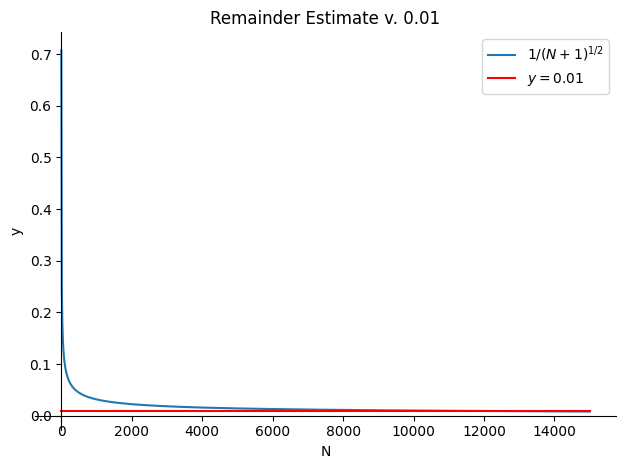

In [15]:
# Remainder Estimate: alternating series, |R_N| <= b_{N+1} = 1/(N+1)^(1/2)
N = sp.Symbol('N', positive=True)
upper_bound = 1 / (N+1)**sp.Rational(1,2)

p = plot(upper_bound, (N, 1, 15000), show=False, label='$1/(N+1)^{1/2}$')
p2 = plot(sp.Rational(1,100), (N, 1, 15000), show=False, line_color='red', label='$y=0.01$')
p.append(p2[0])
p.legend = True
p.title = 'Remainder Estimate v. 0.01'
p.xlabel = 'N'
p.ylabel = 'y'
p.show()


In [16]:
N = sp.Symbol('N', positive=True)
sol = sp.nsolve(1/(N+1)**sp.Rational(1,2) - sp.Rational(1,100), N, 10000)
print(f'N = {sol}')
print(f'We need {int(sp.ceiling(sol))} terms to sum the series to within 0.01.')


N = 9999.00000000000
We need 9999 terms to sum the series to within 0.01.


#### 1b

In [17]:
n = sp.Symbol('n')
N_terms = 9999
partial_sum = sum([(-1)**(k-1) / k**0.5 for k in range(1, N_terms + 1)])
print(f'Sum to <= 0.01: {partial_sum}')


Sum to <= 0.01: 0.60989876842163


#### 1c

In [18]:
print('The series is not absolutely convergent.')
print('Taking abs values gives the series sum of 1/n^(1/2), which is a p-series with p = 1/2.')
print('Since p = 1/2 <= 1, the p-series diverges.')
print('Original series is only conditionally convergent (converges by the Alternating Series Test, but not absolutely).')


The series is not absolutely convergent.
Taking abs values gives the series sum of 1/n^(1/2), which is a p-series with p = 1/2.
Since p = 1/2 <= 1, the p-series diverges.
Original series is only conditionally convergent (converges by the Alternating Series Test, but not absolutely).


#### 1d

Dirichlet eta function:


Sum((-1)**(n - 1)/n**x, (n, 1, oo))

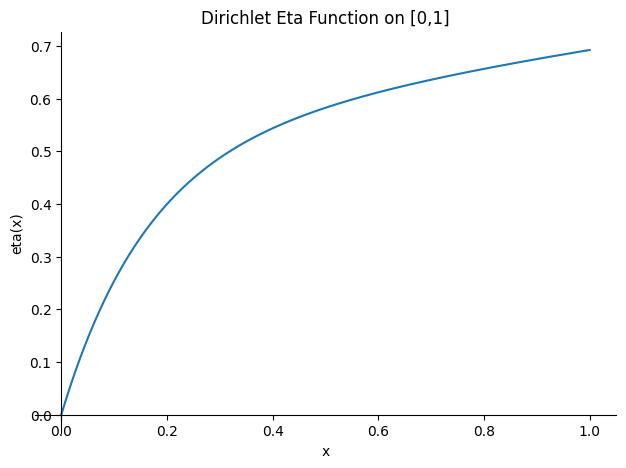

In [19]:
n, x = sp.symbols('n x')

eta = sp.Sum((-1)**(n-1) / n**x, (n, 1, sp.oo))
print('Dirichlet eta function:')
display(eta)

eta_approx = sp.Sum((-1)**(n-1) / n**x, (n, 1, 500)).doit()
plot(eta_approx, (x, 0, 1), title='Dirichlet Eta Function on [0,1]', xlabel='x', ylabel='eta(x)')


### Question 2

#### 2a

In [20]:
n, x = sp.symbols('n x')

ratio = sp.Abs(x)**3 / ((3*n - 1)*(3*n))
L = sp.limit(ratio, n, sp.oo)
print(f'Limit of |a_n / a_{{n-1}}| as n -> oo: {L}')
print('Since the limit is 0 < 1 for all finite x, the series converges for all real x.')
print(f'Interval of convergence: ({-sp.oo}, {sp.oo})')


Limit of |a_n / a_{n-1}| as n -> oo: 0
Since the limit is 0 < 1 for all finite x, the series converges for all real x.
Interval of convergence: (-oo, oo)


#### 2b

In [21]:
x = sp.Symbol('x')

# a_0 = 1
# a_1 = x^3 / (2*3)
# a_2 = x^3 / (5*6) * a_1 = x^6 / (2*3*5*6)
# a_3 = x^3 / (8*9) * a_2 = x^9 / (2*3*5*6*8*9)

s1 = 1 + x**3 / (2*3)
s2 = s1 + x**6 / (2*3*5*6)
s3 = s2 + x**9 / (2*3*5*6*8*9)

print('s1 =', sp.expand(s1))
print('s2 =', sp.expand(s2))
print('s3 =', sp.expand(s3))


s1 = x**3/6 + 1
s2 = x**6/180 + x**3/6 + 1
s3 = x**9/12960 + x**6/180 + x**3/6 + 1


#### 2c

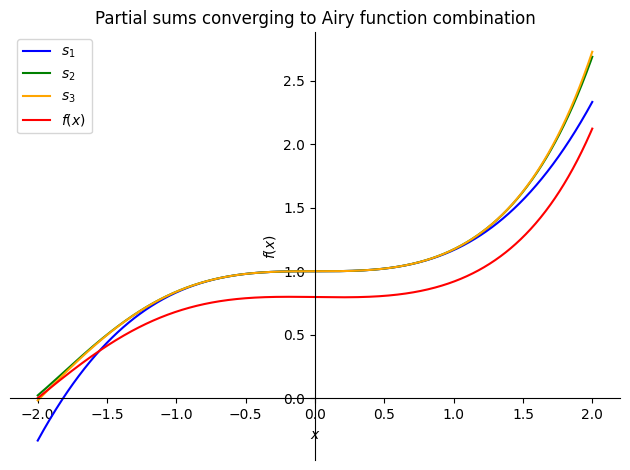

In [22]:
# f(x) = cbrt(9*Gamma(2/3))*Ai(x)/2 + (3*Gamma(2/3))^(1/6)*Bi(x)/2
x = sp.Symbol('x')

f = (9 * sp.gamma(sp.Rational(2,3)))**sp.Rational(1,3) * sp.airyai(x) / 2 + \
    (3 * sp.gamma(sp.Rational(2,3)))**sp.Rational(1,6) * sp.airybi(x) / 2

s1_expr = 1 + x**3 / 6
s2_expr = s1_expr + x**6 / 180
s3_expr = s2_expr + x**9 / 12960

p1 = plot(s1_expr, (x, -2, 2), show=False, label='$s_1$', line_color='blue')
p2 = plot(s2_expr, (x, -2, 2), show=False, label='$s_2$', line_color='green')
p3 = plot(s3_expr, (x, -2, 2), show=False, label='$s_3$', line_color='orange')
p4 = plot(f, (x, -2, 2), show=False, label='$f(x)$', line_color='red')

p1.append(p2[0])
p1.append(p3[0])
p1.append(p4[0])
p1.legend = True
p1.title = 'Partial sums converging to Airy function combination'
p1.show()


### Question 3

#### 3a

In [23]:
def rising_factorial(a, n):
    result = 1
    for i in range(n):
        result *= (a + i)
    return result

print(f'(7)_5 = {rising_factorial(7, 5)}')
print(f'(5)_7 = {rising_factorial(5, 7)}')
print(f'(-2)_4 = {rising_factorial(-2, 4)}')


(7)_5 = 55440
(5)_7 = 1663200
(-2)_4 = 0


#### 3b

In [24]:
print('(a)_{n+1} / (a)_n = (a+n)')
print('Because (a)_{n+1} = a*(a+1)*...*(a+n) = (a)_n * (a+n)')
print('So dividing both sides by (a)_n gives (a+n).')
print()


n = sp.Symbol('n', positive=True)
a, b, c, x = sp.symbols('a b c x', positive=True)

ratio = (a + n) * (b + n) / ((c + n) * (n + 1)) * sp.Abs(x)
L = sp.limit(ratio, n, sp.oo)
print(f'Limit of |c_{{n+1}}/c_n| as n -> oo: {L}')
print('By the Ratio Test, the series converges when |x| < 1.')
print('Therefore the radius of convergence is R = 1.')


(a)_{n+1} / (a)_n = (a+n)
Because (a)_{n+1} = a*(a+1)*...*(a+n) = (a)_n * (a+n)
So dividing both sides by (a)_n gives (a+n).

Limit of |c_{n+1}/c_n| as n -> oo: x
By the Ratio Test, the series converges when |x| < 1.
Therefore the radius of convergence is R = 1.


#### 3c

In [25]:
import math

def rising_factorial(a, n):
    result = 1
    for i in range(n):
        result *= (a + i)
    return result


print('H(1,1,1,x):')
print('Since (1)_n = n!, each term simplifies to (n!)^2/((n!)(n!)) * x^n = x^n.')
print('So H(1,1,1,x) = sum of x^n from n=0 to inf = 1/(1-x), the geometric series.')
print()
print('First 10 terms of H(1,1,1,x):')
for k in range(10):
    coeff = rising_factorial(1,k)*rising_factorial(1,k) / (rising_factorial(1,k)*math.factorial(k))
    print(f'  n={k}: {coeff} * x^{k}')

print()

print('x * H(1,1,2,-x):')
print('(2)_n = (n+1)!, so each term of H is (n!)^2/((n+1)!*n!) * (-x)^n = (-x)^n/(n+1).')
print('Multiplying by x: sum of (-1)^n * x^{n+1}/(n+1) = ln(1+x), the Mercator series.')
print()
print('First 10 terms of x*H(1,1,2,-x):')
for k in range(10):
    coeff = sp.Rational((-1)**k, k+1)
    print(f'  n={k}: {coeff} * x^{k+1}')


H(1,1,1,x):
Since (1)_n = n!, each term simplifies to (n!)^2/((n!)(n!)) * x^n = x^n.
So H(1,1,1,x) = sum of x^n from n=0 to inf = 1/(1-x), the geometric series.

First 10 terms of H(1,1,1,x):
  n=0: 1.0 * x^0
  n=1: 1.0 * x^1
  n=2: 1.0 * x^2
  n=3: 1.0 * x^3
  n=4: 1.0 * x^4
  n=5: 1.0 * x^5
  n=6: 1.0 * x^6
  n=7: 1.0 * x^7
  n=8: 1.0 * x^8
  n=9: 1.0 * x^9

x * H(1,1,2,-x):
(2)_n = (n+1)!, so each term of H is (n!)^2/((n+1)!*n!) * (-x)^n = (-x)^n/(n+1).
Multiplying by x: sum of (-1)^n * x^{n+1}/(n+1) = ln(1+x), the Mercator series.

First 10 terms of x*H(1,1,2,-x):
  n=0: 1 * x^1
  n=1: -1/2 * x^2
  n=2: 1/3 * x^3
  n=3: -1/4 * x^4
  n=4: 1/5 * x^5
  n=5: -1/6 * x^6
  n=6: 1/7 * x^7
  n=7: -1/8 * x^8
  n=8: 1/9 * x^9
  n=9: -1/10 * x^10


#### 3d

In [26]:
import math

def C(n, k):
    if k < 0 or k > n:
        return 0
    return math.factorial(n) // (math.factorial(n - k) * math.factorial(k))

def P(N, M, n, k):
    return sp.Rational(C(M, k) * C(N - M, n - k), C(N, n))

result = P(20, 8, 10, 4)
print(f'P(20, 8, 10, 4) = {result} ≈ {float(result):.6f}')


P(20, 8, 10, 4) = 1470/4199 ≈ 0.350083
